<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a> |
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a> |
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a> |
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# **Estatística Básica - Conceitos e Aplicações**

## **Introdução**

A estatística envolve técnicas para coletar, organizar, descrever, analisar e interpretar dados, ou provenientes de experimentos, ou vindos de estudos observacionais (Barbetta, 2010). Essa lógica já foi aplicada nas etapas anteriores deste notebook, nas quais organizamos os dados em tabelas de frequência e representamos as variáveis por meio de gráficos para apoiar a interpretação dos resultados.

<p align="center">
  <img src="figs/fig1_1.png" width="400">
</p>

**Fig. 12 - Técnicas envolvidas no processo estatístico**. Fluxo inicia na coleta, organização, descrição, análise e interpretação dos dados. Fonte: Autor, 2026.

A análise estatística de dados geralmente tem por objetivo tomadas de decisões, resoluções de problemas ou produção de conhecimento. Mas novos conhecimentos normalmente geram novos problemas de pesquisa, resultando em um processo iterativo (Barbetta, 2010).

<p align="center">
  <img src="figs/fig1_2.png" width="320">
</p>

**Fig. 13 - Processo iterativo das pesquisas empíricas**. Ciclo iniciando nas pesquisas, dados, informações e novos conhecimento e/ou problemas. Fonte: Autor, 2026.

## **Análise Exploratória de Dados**

Na análise exploratória de dados, além de **descrever os dados**, busca-se **compreender características do processo** que os gerou. Por meio do uso adequado de **tabelas, gráficos e medidas estatísticas**, é possível identificar padrões e estruturas que não são evidentes nos dados brutos.

<p align="center">
  <img src="figs/fig1_3.png" width="600">
</p>

**Fig. 1 – Estrutura de um conjunto de dados**. As linhas representam os indivíduos ou casos observados, enquanto as colunas correspondem às variáveis associadas a cada indivíduo (por exemplo, sexo, idade, nível de instrução e provedor). O conjunto de dados é formado pela combinação sistemática dessas observações, organizando a informação de cada indivíduo segundo as variáveis analisadas. Fonte: Adaptado de Barbetta, 2010.



A partir desta estrutura de dados, as próximas células executam o fluxo da análise: importação das bibliotecas, preparação de funções, download e carregamento do `dataset/api.csv`, seguido da análise exploratória inicial com inspeção das variáveis e de suas distribuições.

### **Importação das bibliotecas**

In [2]:
import os
import pandas as pd
import numpy as np
from gdown import download
import matplotlib.pyplot as plt


### **Configurações iniciais**

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    'figure.figsize': (7, 4.5),
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

### **Funções**

In [4]:
# Criar pastas do projeto (imagens gerais e figuras dos notebooks)
if not os.path.exists('imgs'):
    os.makedirs('imgs')

print('Pasta pronta: imgs/')

Pasta pronta: imgs/


In [5]:
# Definir a função download_from_drive
def download_from_drive(link,filename):

    # Criar a pasta para download
    foldername = filename.split('/')[0]
    if not os.path.exists(foldername):
        os.makedirs(foldername)
    else:
        print(f'A pasta {foldername} já existe!')

    # Extrair o ID do arquivo a partir do link do Google Drive
    file_id = link.split('/')[5]
    # Criar a URL de download usando o ID do arquivo
    url = f'https://drive.google.com/uc?id={file_id}'
    download(url, filename, quiet = False)

### **Download do dataset e imagens**

In [6]:
# Download arquivo CSV e figuras PNG
url_dataset = 'https://drive.google.com/file/d/1NBGGyGyR9NInnKo9aS5JnrN79AOXJzrh/view?usp=share_link'
dst_dataset = 'dataset/api.csv'

download_from_drive(url_dataset,dst_dataset)

A pasta dataset já existe!


Downloading...
From: https://drive.google.com/uc?id=1NBGGyGyR9NInnKo9aS5JnrN79AOXJzrh
To: /Users/carubbi/Documents/projects/T199/dataset/api.csv
100%|██████████| 444k/444k [00:00<00:00, 2.13MB/s]


### **Descrição do dataset**

**Performance estudantil em escolas da Califórnia**

Descrição
O API é um índice numérico na escala de 200 a 1.000 que indica o desempenho estudantil de uma escola ou distrito em testes anuais. O API é calculado para toda a escola, incluindo alunos desfavorecidos socioeconômicos, alunos com deficiência físico-motora e não proficientes em inglês [1].

As pontuações do API para escolas de mesma graduação (ensino fundamental, médio e superior) são classificadas em 'decis', com 1 representando os 10% de escolas com desempenho mais baixo e 10 os 10% de desempenho mais alto. As escolas têm dois rankings: (1) um ranking estadual que compara cada escola com todas as outras escolas do mesmo tipo no estado e (2) um ranking de escolas semelhantes que compara cada escola com 100 outras com populações de alunos similares e outras características [1].

O Conselho Estadual de Educação da Califórnia definiu a meta de API estadual em 800 de 1.000. A Lei de responsabilidade das escolas públicas exige que a maioria das escolas melhore seu desempenho a cada ano em 5% da diferença entre sua API e a meta estadual de 800, com uma meta mínima de crescimento de cinco pontos [1].

Formato
Dataframe com 5423 observações (linhas) e 11 variáveis (colunas).

- **ID**: Identificação única da escola.
- **TIPO**: Nível de ensino da escola (Fundamental, Médio e Superior).
- **NOME**: Nome da escola (15 caracteres).
- **API00**: Índice de desempenho acadêmico em 2000.
- **API99**: Índice de desempenho acadêmico em 1999.
- **META**: Meta de crescimento no API.
- **REFS**: Porcentagem de alunos elegíveis para refeição subsidiada.
- **NPI**: Porcentagem de alunos não proficientes em inglês.
- **EDU**: Média do nível de educação dos pais.
- **TEST_INSC**: Número de alunos inscritos.
- **TEST_NUM**: Número de alunos testados para o API.

**Fonte**

Os dados foram obtidos pela pesquisa do setor acadêmico da Universidade da Califórnia em Los Angeles (UCLA).
[1] https://www.ed-data.org/article/Understanding-the-Academic-Performance-Index-(API)

Referência
O programa API foi descontinuado no final de 2018 e demais informações estão em https://www.cde.ca.gov/re/pr/api.asp

Califórnia é um dos 50 estados dos Estados Unidos, localizado na região dos estados do Pacífico. É o estado mais populoso do país, com 39.538.223 habitantes e o terceiro em extensão territorial, superado apenas pelo Alasca e pelo Texas (Wikipedia, 2021).

### **Carregamento do dataset**

In [7]:
# Carregar o arquivo CSV com todas as colunas como texto
df = pd.read_csv('dataset/api.csv', dtype=str)

# Exibir as cinco primeiras linhas
df.head(3)


,ID,TIPO,NOME,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI
0,1611190130229,Superior,Alameda High,731,693,5,3.45000004768372,1278,1090,14,16
1,1611190132878,Superior,Encinal High,622,589,11,3.05999994277954,1113,840,20,18
2,1611196000004,Medio,Chipman Middle,622,572,11,2.8199999332428,546,472,55,25


### **Formatação das colunas (variáveis)**

In [8]:
# Define grupos de colunas por tipo (nomes originais do CSV)
vars_quant_discreta = [
    'API00',
    'API99',
    'META',
    'TEST_INSC',
    'TEST_NUM',
    'REFS',
    'NPI',
]
vars_quant_continua = ['EDU']
vars_qual_nominal = ['ID', 'NOME']

# Converte colunas numéricas
for col in vars_quant_discreta:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
for col in vars_quant_continua:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Garante colunas textuais como string
for col in vars_qual_nominal:
    df[col] = df[col].astype('string')

print(df.dtypes)


ID            string
TIPO             str
NOME          string
API00          Int64
API99          Int64
META           Int64
EDU          float64
TEST_INSC      Int64
TEST_NUM       Int64
REFS           Int64
NPI            Int64
dtype: object


In [9]:
# Define TIPO como categórica ordinal
ordem_var_qual_ordinal_tipo = ['Fundamental', 'Medio', 'Superior']
dtype_tipo_ordinal = pd.CategoricalDtype(
    categories=ordem_var_qual_ordinal_tipo,
    ordered=True
)
df['TIPO'] = pd.Categorical(df['TIPO'], dtype=dtype_tipo_ordinal)

# Exibe os tipos finais das colunas
df.dtypes


ID             string
TIPO         category
NOME           string
API00           Int64
API99           Int64
META            Int64
EDU           float64
TEST_INSC       Int64
TEST_NUM        Int64
REFS            Int64
NPI             Int64
dtype: object

### **Compreensão Geral do Dataset**

In [10]:
# Exibir as informações básicas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5423 entries, 0 to 5422
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   ID         5423 non-null   string  
 1   TIPO       5423 non-null   category
 2   NOME       5423 non-null   string  
 3   API00      5423 non-null   Int64   
 4   API99      5423 non-null   Int64   
 5   META       5423 non-null   Int64   
 6   EDU        5423 non-null   float64 
 7   TEST_INSC  5423 non-null   Int64   
 8   TEST_NUM   5423 non-null   Int64   
 9   REFS       5423 non-null   Int64   
 10  NPI        5423 non-null   Int64   
dtypes: Int64(7), category(1), float64(1), string(2)
memory usage: 466.3 KB


## **Dados e Variáveis**

Os dados podem ser observações de **variáveis qualitativas ou de variáveis quantitativas**. E as técnicas de análise serão diferentes para cada caso. Quando os possíveis resultados de uma variável são números de certa escala, dizemos que essa variável é quantitativa. Quando os possíveis resultados são atributos ou qualidades, a variável é dita qualitativa (Barbetta, 2010).

Dentre as variáveis qualitativas, ainda podemos fazer uma distinção entre dois tipos: **variável qualitativa nominal**, para a qual não existe nenhuma ordenação nas possíveis realizações, e **variável qualitativa ordinal**, para a qual existe uma ordem nos seus resultados (MORETIN, 2017).

<p align="center">
  <img src="figs/fig1_4.png" width="600">
</p>

**Fig. 2 – Classificação das variáveis estatísticas.** O diagrama ilustra a distinção entre variáveis quantitativas, que geram dados numéricos passíveis de operações aritméticas, e variáveis qualitativas ou categóricas, que produzem dados classificados em categorias ou rótulos. Essa classificação orienta a escolha das técnicas estatísticas adequadas para análise dos dados. Fonte: Carubbi, 2026.

#### **Classificação das variáveis do dataset**

- `ID`: qualitativa nominal. É um identificador (rótulo), não mede quantidade.

- `TIPO`: qualitativa ordinal. São categorias com ordem natural de nível de ensino.

- `NOME`: qualitativa nominal. Nome da escola é categoria sem ordem.

- `API00`: quantitativa discreta. Índice em pontos inteiros, então valores possíveis são contáveis.

- `API99`: quantitativa discreta. Mesmo caso do índice de 2000: pontos inteiros e contáveis.

- `META`: quantitativa discreta. Meta em pontos inteiros de crescimento.

- `TEST_INSC`: quantitativa discreta. Contagem de alunos inscritos (não existe aluno fracionado).

- `TEST_NUM`: quantitativa discreta. Contagem de alunos testados.

- `REFS`: quantitativa discreta. Percentual registrado em inteiros no dataset (0, 1, 2, ...).

- `NPI`: quantitativa discreta. Percentual também registrado em valores inteiros.

- `EDU`: quantitativa contínua. Média com casas decimais, podendo assumir valores em intervalo contínuo.


### **Análise de Variáveis Qualitativas**

Um dos primeiros passos para analisar um arquivo de dados, especialmente quando o número de observações for grande, é a distribuição de frequências de cada variável (por exemplo, no `api.csv`, para variáveis qualitativas como `TIPO` e `NOME`; já `ID` funciona como identificador nominal).

#### **Tabela de Frequência Absoluta e Relativa**

In [11]:
# Verificar a distribuição de TIPO após a formatação
df['TIPO'].value_counts().sort_index()

TIPO
Fundamental    3812
Medio           897
Superior        714
Name: count, dtype: int64

In [12]:
# Conta a frequência de cada categoria de TIPO
freq_tipo = df['TIPO'].value_counts().sort_index()

# Cria o DataFrame com frequência absoluta
df_freq_tipo = pd.DataFrame({
    'TIPO': freq_tipo.index,
    'FREQ_ABSOLUTA': freq_tipo.values
})

# Calcula a frequência relativa
df_freq_tipo['FREQ_RELATIVA'] = (
    df_freq_tipo['FREQ_ABSOLUTA'] /
    df_freq_tipo['FREQ_ABSOLUTA'].sum()
)

# Exibe o resultado
df_freq_tipo

,TIPO,FREQ_ABSOLUTA,FREQ_RELATIVA
0,Fundamental,3812,0.702932
1,Medio,897,0.165407
2,Superior,714,0.131661


#### **Gráfico de Barras**

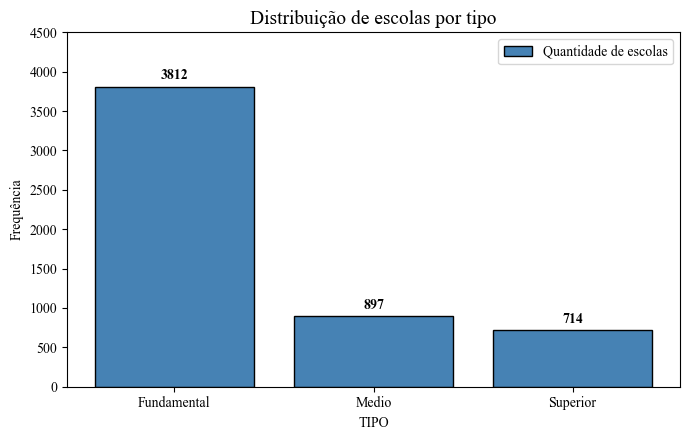

In [13]:
# Gerar gráfico de barras para a variável TIPO
# Conta escolas por categoria de TIPO
contagem_tipo = df['TIPO'].value_counts().sort_index()

# Cria a figura (fig) e o eixo do gráfico (ax)
fig, ax = plt.subplots()

# Plota barras de frequência por categoria
barras = ax.bar(
    contagem_tipo.index,
    contagem_tipo.values,
    color='steelblue',
    edgecolor='black',
    label='Quantidade de escolas'
)

# Coloca os rótulos de contagem no topo das barras
ax.bar_label(
    barras,
    fmt='%d',
    label_type='edge',
    padding=3,
    color='black',
    fontsize=10,
    fontweight='bold'
)

# Define título e nomes dos eixos
ax.set_title('Distribuição de escolas por tipo')
ax.set_xlabel('TIPO')
ax.set_ylabel('Frequência')

# Adiciona folga de 500 unidades no limite superior do eixo vertical
ax.set_ylim(0, 4500)

# Mostra legenda
ax.legend()

# Ajusta layout e exibe
plt.tight_layout()
plt.savefig('figs/fig1_5.png', format='png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


**Fig. 3 - Distribuição de escolas por tipo (TIPO)**. A figura apresenta a frequência de escolas por categoria de ensino. A interpretação apoia a leitura de composição categórica inicial dos dados. Fonte: Carubbi, 2026.

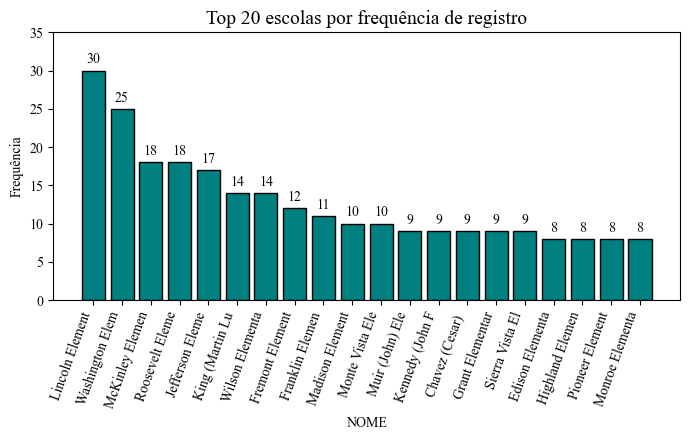

In [15]:
# Gerar gráfico de barras para a variável NOME
# Conta e seleciona os 20 nomes mais frequentes
contagem_nome_top20 = df['NOME'].value_counts().head(20)

# Cria a figura (fig) e o eixo do gráfico (ax)
fig, ax = plt.subplots()

# Plota barras de frequência por nome
barras = ax.bar(
    contagem_nome_top20.index,
    contagem_nome_top20.values,
    color='teal',
    edgecolor='black'
)

# Define título e nomes dos eixos
ax.set_title('Top 20 escolas por frequência de registro')
ax.set_xlabel('NOME')
ax.set_ylabel('Frequência')
ax.set_ylim(0, 35)

# Rotaciona rótulos para melhorar leitura
plt.xticks(rotation=70, ha='right')

# Exibe rótulos centralizados no topo externo das barras
ax.bar_label(
    barras,
    fmt='%d',
    label_type='edge',
    padding=3
)

# Ajusta layout e exibe
plt.tight_layout()
plt.savefig('figs/fig1_7.png', format='png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

**Fig. 4 - Top 20 escolas por frequência de registro (NOME)**. A figura mostra as escolas com maior frequência no conjunto analisado. A interpretação destaca as categorias mais recorrentes na base. Fonte: Carubbi, 2026.

#### **Gráfico de Pizza**

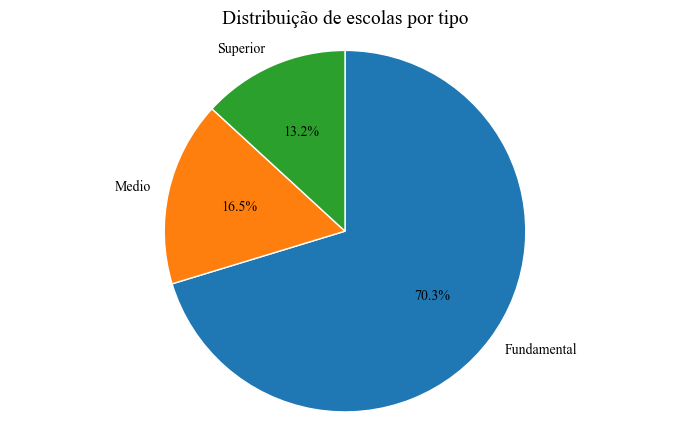

In [14]:
# Gerar gráfico de pizza para a variável TIPO
# Cria a figura (fig) e o eixo do gráfico (ax)
fig, ax = plt.subplots()

# Plota gráfico de pizza com percentuais
ax.pie(
    contagem_tipo.values,
    labels=contagem_tipo.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white'}
)

# Define título e mantém formato circular
ax.set_title('Distribuição de escolas por tipo')
ax.axis('equal')
plt.tight_layout()
plt.savefig('figs/fig1_6.png', format='png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


**Fig. 5 - Distribuição de escolas por tipo (TIPO).** A figura apresenta a participação percentual de cada categoria de TIPO. A interpretação reforça a análise de proporções na etapa descritiva. Fonte: Carubbi, 2026.

#### **Conversão de variável contínua para categórica (nominal e ordinal)**

Ao discretizar uma variável contínua, há **ganho de interpretabilidade** e, ao mesmo tempo, **perda de granularidade numérica**. Portanto, os pontos de corte devem ser definidos por critério técnico (teórico, regulatório ou orientado por quantis), conforme o objetivo da análise.


##### **Exemplo 1 - Categórica nominal**
Neste exemplo, o distrito é identificado a partir do campo `ID`, usando os **7 primeiros dígitos** (`CCDDDDD`) como código distrital. Essa variável é tratada como **categórica nominal**, sem ordenação entre categorias.


In [17]:
# Exemplo nominal: distrito derivado dos 7 primeiros dígitos de ID (CCDDDDD)
id_str = df['ID'].astype(str).str.strip()

# Padroniza com zero à esquerda e extrai o código de distrito
id_pad = id_str.str.zfill(14)
df['DISTRITO_ID'] = id_pad.str[:7].astype('category')

print('Tipo da variável nominal:', df['DISTRITO_ID'].dtype)
print('Quantidade de distritos únicos:', df['DISTRITO_ID'].nunique())
df['DISTRITO_ID'].value_counts(dropna=False).head(15)


Tipo da variável nominal: category
Quantidade de distritos únicos: 705


DISTRITO_ID
1964733    531
3768338    126
3868478     91
1062166     77
1964725     76
0161259     70
3467439     67
3066522     58
3467447     54
3667876     51
0761796     47
3066670     44
1563321     38
3968676     37
4369666     37
Name: count, dtype: int64

##### **Exemplo 2 - Categórica ordinal (com ordem)**
Agora, `EDU` é convertida em faixas ordenadas (`Baixa`, `Média`, `Alta`) com cortes explícitos, preservando a noção de **gradiente** entre categorias.


In [19]:
# Exemplo ordinal: discretização de EDU em faixas ordenadas
edu = df['EDU'].astype(float)
ordem_edu = ['Baixa', 'Média', 'Alta']
nome_col = 'EDU_CAT_ORD'

df[nome_col] = pd.cut(
    edu,
    bins=[-np.inf, 2.0, 3.0, np.inf],
    labels=ordem_edu,
    include_lowest=True,
    right=True
)

df[nome_col] = pd.Categorical(
    df['EDU_CAT_ORD'],
    categories=ordem_edu,
    ordered=True
)

print('Tipo da variável ordinal:', df[nome_col].dtype)
df[nome_col].value_counts(dropna=False).sort_index()


Tipo da variável ordinal: category


EDU_CAT_ORD
Baixa     914
Média    2917
Alta     1592
Name: count, dtype: int64

#### **Tabela de contingência entre variáveis categóricas**

Com as categorias definidas, podemos avaliar a associação entre `TIPO` e `EDU_CAT_ORDINAL` por meio de uma **tabela de contingência** com frequências absolutas e proporções por linha.


In [21]:
# Crosstab de contagens (com totais)
ct_tipo_edu = pd.crosstab(
    df['TIPO'],
    df['EDU_CAT_ORD'],
    margins=True
)
ct_tipo_edu


EDU_CAT_ORD,Baixa,Média,Alta,All
TIPO,,,,
Fundamental,749,2096,967,3812
Medio,103,481,313,897
Superior,62,340,312,714
All,914,2917,1592,5423


In [22]:
# Crosstab normalizada por linha (proporções dentro de cada TIPO)
ct_tipo_edu_row = pd.crosstab(
    df['TIPO'],
    df['EDU_CAT_ORD'],
    normalize='index'
).round(3)
ct_tipo_edu_row


EDU_CAT_ORD,Baixa,Média,Alta
TIPO,,,
Fundamental,0.196,0.550,0.254
Medio,0.115,0.536,0.349
Superior,0.087,0.476,0.437


### **Análise de Variáveis Quantitativas**

A variável quantitativa pode ser **contínua**, quando assume qualquer valor entre dois limites (ex: `EDU`, que aparece com casas decimais como média de nível educacional), ou pode ser **discreta**, quando só pode assumir valores pertencentes a um conjunto enumerável (ex: `TEST_INSC`, `TEST_NUM`, `API00`, `API99`, `META`, `REFS` e `NPI`, registrados em valores inteiros no dataset).

#### **Estatísticas Básicas**

In [ ]:
# Preparar base numérica para os gráficos quantitativos
# Observação: as conversões de tipo já foram feitas na etapa de carregamento
cols_qt = [
    'API00', 'API99', 'META', 'EDU',
    'TEST_INSC', 'TEST_NUM', 'REFS', 'NPI'
]
df_qt = df[cols_qt].copy()

df_qt.describe().T

,count,mean,std,min,25%,50%,75%,max
API00,5423.0,637.561129,110.662573,346.0,552.0,645.0,726.0,878.0
API99,5423.0,602.771529,112.030742,302.0,513.0,608.0,694.0,799.0
META,5423.0,9.900609,5.582014,1.0,5.0,10.0,14.0,25.0
EDU,5423.0,2.648621,0.61465,1.0,2.18,2.7,3.09,5.0
TEST_INSC,5423.0,632.98451,480.669244,101.0,334.0,479.0,735.5,4117.0
TEST_NUM,5423.0,525.813756,401.832128,100.0,281.0,405.0,611.0,3862.0
REFS,5423.0,53.342062,28.381291,0.0,29.0,53.0,78.0,100.0
NPI,5423.0,25.297068,21.663843,0.0,7.0,19.0,38.0,95.0


#### **Histograma**

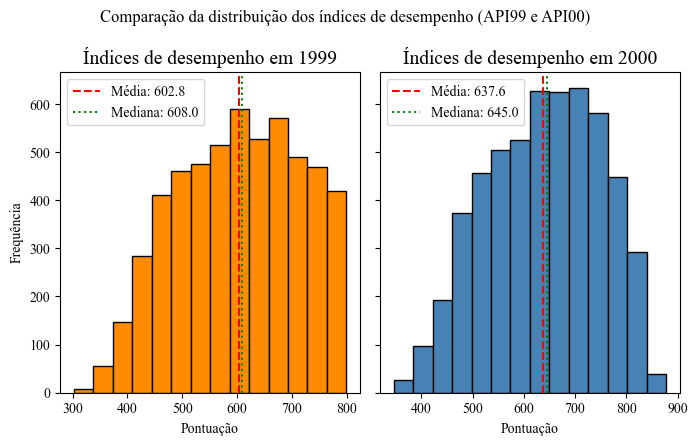

In [ ]:
# Histograma: API00 e API99
# Observação: os bins foram definidos pela regra de Sturges.
# Cria a figura (fig) e dois eixos de gráfico (axes)
fig, axes = plt.subplots(1, 2, sharey=True)

# Seleciona as variáveis quantitativas
api99 = df_qt['API99']
api00 = df_qt['API00']

# Plota API99 e destaca média e mediana
axes[0].hist(api99, bins='sturges', color='darkorange', edgecolor='black')
media_99 = api99.mean()
mediana_99 = api99.median()
axes[0].axvline(
    media_99,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Média: {media_99:.1f}'
)
axes[0].axvline(
    mediana_99,
    color='green',
    linestyle=':',
    linewidth=1.5,
    label=f'Mediana: {mediana_99:.1f}'
)
axes[0].set_title('Índices de desempenho em 1999')
axes[0].set_xlabel('Pontuação')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Plota API00 e destaca média e mediana
axes[1].hist(api00, bins='sturges', color='steelblue', edgecolor='black')
media_00 = api00.mean()
mediana_00 = api00.median()
axes[1].axvline(
    media_00,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Média: {media_00:.1f}'
)
axes[1].axvline(
    mediana_00,
    color='green',
    linestyle=':',
    linewidth=1.5,
    label=f'Mediana: {mediana_00:.1f}'
)
axes[1].set_title('Índices de desempenho em 2000')
axes[1].set_xlabel('Pontuação')
axes[1].legend()

# Ajusta layout e exibe
fig.suptitle(
    'Comparação da distribuição dos índices de desempenho (API99 e API00)'
)
plt.tight_layout()
plt.savefig('figs/fig1_8.png', format='png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


**Fig. 6 - Comparação da distribuição dos índices de desempenho (API99 e API00).** A figura compara as distribuições dos índices API entre os dois anos. A interpretação permite avaliar diferenças de concentração, dispersão e assimetria. Fonte: Carubbi, 2026.

#### **Diagrama de Caixa (Boxplot)**

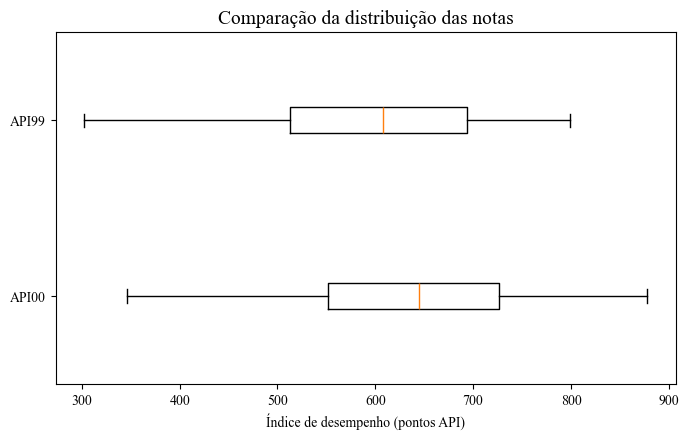

In [ ]:
# Boxplot simples: API00 e API99
# Cria a figura (fig) e o eixo do gráfico (ax)
fig, ax = plt.subplots()

# Desenha o boxplot das duas variáveis quantitativas na horizontal
ax.boxplot(
    [df_qt['API00'], df_qt['API99']],
    tick_labels=['API00', 'API99'],
    vert=False
)

# Define título e rótulo do eixo X
ax.set_title('Comparação da distribuição das notas')
ax.set_xlabel('Índice de desempenho (pontos API)')

# Ajusta layout e exibe
plt.tight_layout()
plt.savefig('figs/fig1_9.png', format='png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


**Fig. 7 - Comparação da distribuição das notas (API00 e API99).** A figura resume as distribuições de API00 e API99 em formato de boxplot. A interpretação facilita comparar mediana, amplitude interquartil e possíveis outliers. Fonte: Carubbi, 2026.

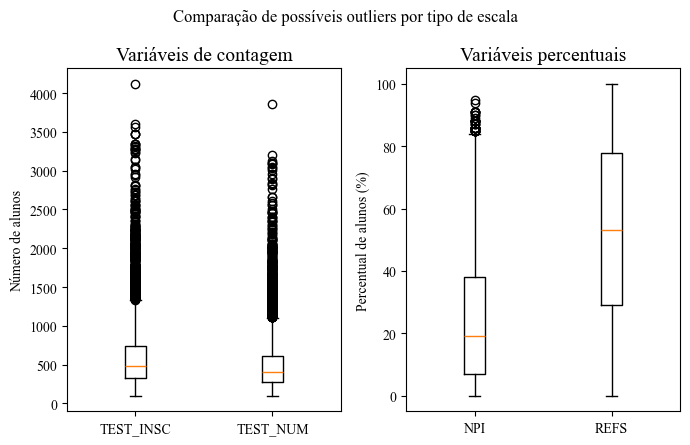

In [ ]:
# Boxplot para observar possíveis outliers (separado por escala)
# Cria a figura (fig) e dois eixos de gráfico (axes)
fig, axes = plt.subplots(1, 2, sharey=False)

# Variáveis de contagem (escala maior)
vars_contagem = ['TEST_INSC', 'TEST_NUM']
dados_contagem = [df_qt[v] for v in vars_contagem]
axes[0].boxplot(dados_contagem, tick_labels=vars_contagem)
axes[0].set_title('Variáveis de contagem')
axes[0].set_ylabel('Número de alunos')

# Variáveis percentuais (escala menor)
vars_percentual = ['NPI', 'REFS']
dados_percentual = [df_qt[v] for v in vars_percentual]
axes[1].boxplot(dados_percentual, tick_labels=vars_percentual)
axes[1].set_title('Variáveis percentuais')
axes[1].set_ylabel('Percentual de alunos (%)')

# Ajustes finais
fig.suptitle('Comparação de possíveis outliers por tipo de escala')
plt.tight_layout()
plt.savefig('figs/fig1_10.png', format='png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


**Fig. 8 - Comparação de possíveis outliers por tipo de escala (TEST_INSC, TEST_NUM, NPI e REFS).** A figura separa variáveis de contagem e percentuais em painéis distintos. A interpretação melhora a leitura de outliers sem distorção por escalas diferentes. Fonte: Carubbi, 2026.

#### **Gráfico de Dispersão**

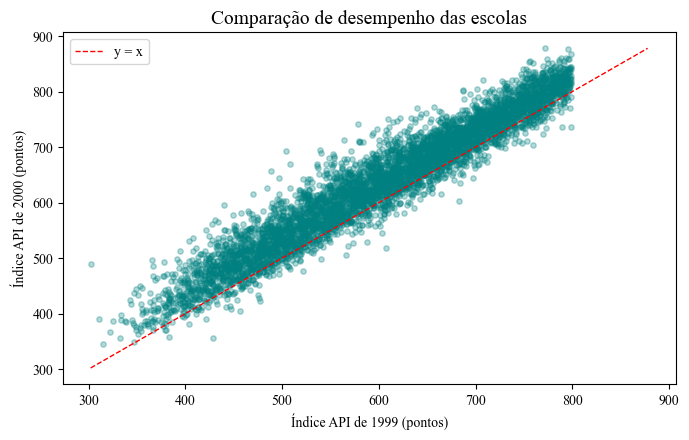

In [ ]:
# Dispersão: API99 x API00 com linha y=x
# Cria a figura (fig) e o eixo do gráfico (ax)
fig, ax = plt.subplots()

# Define variáveis para comparação entre anos
x = df_qt['API99']
y = df_qt['API00']

# Plota os pontos observados
ax.scatter(x, y, alpha=0.3, s=15, color='teal')

# Adiciona linha de referência y=x (desempenho igual nos dois anos)
mn = min(x.min(), y.min())
mx = max(x.max(), y.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='y = x')

# Títulos, eixos e legenda
ax.set_title('Comparação de desempenho das escolas')
ax.set_xlabel('Índice API de 1999 (pontos)')
ax.set_ylabel('Índice API de 2000 (pontos)')
ax.legend()
plt.tight_layout()
plt.savefig('figs/fig1_11.png', format='png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


**Fig. 9 - Comparação de desempenho das escolas (API99 vs API00).** A figura mostra a associação entre API99 e API00 por escola. A interpretação auxilia na avaliação da relação linear entre os dois anos. Fonte: Carubbi, 2026.

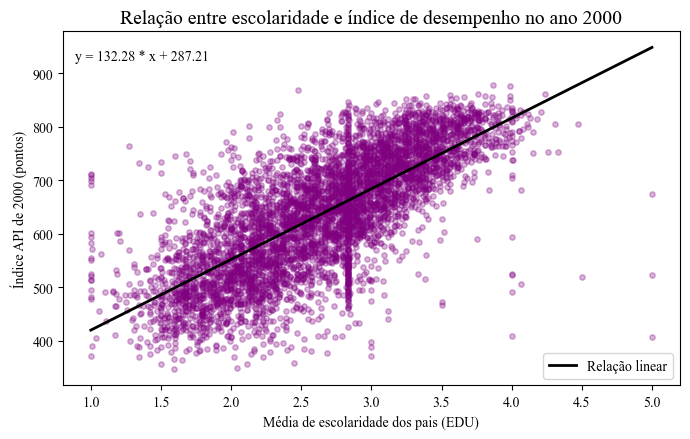

In [ ]:
# Dispersão: EDU x API00 com reta de regressão linear
# Cria a figura (fig) e o eixo do gráfico (ax)
fig, ax = plt.subplots()

# Mantém apenas linhas com dados válidos nas duas variáveis
d = df_qt[['EDU', 'API00']]

# Plota os pontos da amostra
ax.scatter(d['EDU'], d['API00'], alpha=0.3, s=15, color='purple')

# Ajusta e desenha a reta de regressão linear
a, b = np.polyfit(d['EDU'], d['API00'], 1)
x_line = np.linspace(d['EDU'].min(), d['EDU'].max(), 100)
y_line = a * x_line + b
ax.plot(x_line, y_line, color='black', linewidth=2, label='Relação linear')

# Exibe a equação linear no gráfico
eq = f'y = {a:.2f} * x + {b:.2f}'
ax.text(0.02, 0.95, eq, transform=ax.transAxes, va='top')

# Títulos, eixos e legenda
ax.set_title('Relação entre escolaridade e índice de desempenho no ano 2000')
ax.set_xlabel('Média de escolaridade dos pais (EDU)')
ax.set_ylabel('Índice API de 2000 (pontos)')
ax.legend()
plt.tight_layout()
plt.savefig('figs/fig1_12.png', format='png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


**Fig. 10 - Relação entre escolaridade média dos pais e desempenho (EDU e API00) com reta de regressão linear.** A figura apresenta a relação entre EDU e API00 com ajuste linear. A interpretação apoia a leitura da direção e intensidade média da associação. Fonte: Carubbi, 2026.

#### **Mapa de Calor**

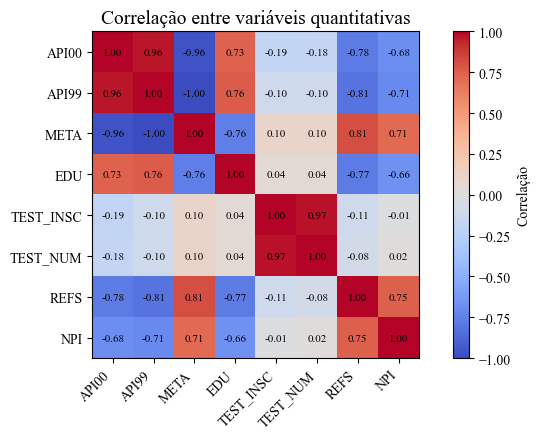

In [ ]:
# Heatmap de correlação das variáveis quantitativas
# Calcula matriz de correlação
corr = df_qt[cols_qt].corr()

# Renderiza matriz como mapa de calor
fig, ax = plt.subplots()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Configura rótulos de linhas/colunas
ax.set_xticks(range(len(cols_qt)))
ax.set_yticks(range(len(cols_qt)))
ax.set_xticklabels(cols_qt, rotation=45, ha='right')
ax.set_yticklabels(cols_qt)

# Exibe os valores de correlação em cada célula
for i in range(len(cols_qt)):
    for j in range(len(cols_qt)):
        ax.text(
            j,
            i,
            f'{corr.iloc[i, j]:.2f}',
            ha='center',
            va='center',
            color='black',
            fontsize=8
        )

# Título e barra de cores
ax.set_title('Correlação entre variáveis quantitativas')
fig.colorbar(im, ax=ax, label='Correlação')
plt.tight_layout()
plt.savefig('figs/fig1_13.png', format='png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


**Fig. 11 - Correlação entre variáveis quantitativas (API00, API99, META, EDU, TEST_INSC, TEST_NUM, REFS e NPI).** A figura sintetiza a matriz de correlação entre variáveis quantitativas. A interpretação orienta a identificação de relações lineares mais fortes e mais fracas. Fonte: Carubbi, 2026.

## **Estatística Descritiva Univariada e Bivariada**

A estatística aplicada pode ser dividida em duas áreas: **estatística descritiva e estatística inferencial**.

A **estatística descritiva** consiste em métodos para sumarizar dados amostrais por meio de tabelas, gráficos e medidas-resumo. Em contraste, a **estatística inferencial** consiste em métodos que utilizam resultados amostrais para tomar decisões ou fazer previsões sobre uma população subjacente (Mann, 2012; Weiss, 2010). Neste notebook, as tabelas de frequência, os histogramas (Fig. 9), os boxplots (Figs. 10 e 11) e os gráficos de dispersão (Figs. 12 e 13) exemplificam a etapa descritiva da análise.


<p align="center">
  <img src="figs/fig1_14.png" width="600">
</p>

**Fig. 14 - Diferenças entre Estatística Descritiva e Inferencial.** Ilustração de um levantamento por amostragem para avaliar a preferência do consumidor. Fonte: Barbetta, 2010.

O termo **univariada** refere-se ao fato de que apenas **uma variável** está sendo considerada. O principal objetivo da estatística univariada é **descrever e resumir os dados**. Quando **duas ou mais variáveis** são analisadas, utiliza-se a análise ou **estatística bivariada ou multivariada**, respectivamente. Nesse caso, o interesse principal recai sobre as **relações entre um conjunto de variáveis**. No notebook, exemplos univariados incluem tabelas de frequência absoluta e relativa, gráficos de barras e de pizza, estatísticas descritivas de uma variável por vez, histogramas e boxplots univariados. Já os exemplos bivariados incluem a tabela de contingência, os gráficos de dispersão, além da matriz/mapa de calor de correlação entre variáveis quantitativas.

## **Saiba mais**

1. [Estatística Descritiva](https://en.wikipedia.org/wiki/Descriptive_statistics)
2. [Estatística Inferencial](https://en.wikipedia.org/wiki/Statistical_inference)
3. [Análise Univariada](https://en.wikipedia.org/wiki/Univariate)
4. [Análise Bivariada](https://en.wikipedia.org/wiki/Bivariate_analysis)
5. [Análise Multivariada](https://en.wikipedia.org/wiki/Multivariate_statistics)

## **Citação**

Estas aulas são baseadas no projeto de e-learning [SOGA-Py](https://www.geo.fu-berlin.de/en/v/soga-py/index.html) que foi desenvolvido no Departamento de Ciências da Terra por Annette Rudolph, Joachim Krois e Kai Hartmann. O contato pode ser realizado por e-mail, pelo endereço [soga[at]zedat.fu-berlin.de](soga[at]zedat.fu-berlin.de).

<p align="left">
  <a href="https://creativecommons.org/licenses/by-sa/4.0/" target="_blank" rel="noopener noreferrer">
    <img src="imgs/cc.png" width="75" alt="Licença Creative Commons BY-SA 4.0">
  </a>
</p>

Você pode utilizar este projeto livremente sob a Licença Creative Commons Attribution-ShareAlike 4.0 International. 

Por favor, cite da seguinte forma: Rudolph, A., Krois, J., Hartmann, K. (2023): Estatística e Análise de Geodados usando Python (SOGA-Py). Departamento de Ciências da Terra, Universidade Livre de Berlim.